=== 开始处理 1990-2030 时空动态制图 (期刊极限大字号出图版) ===


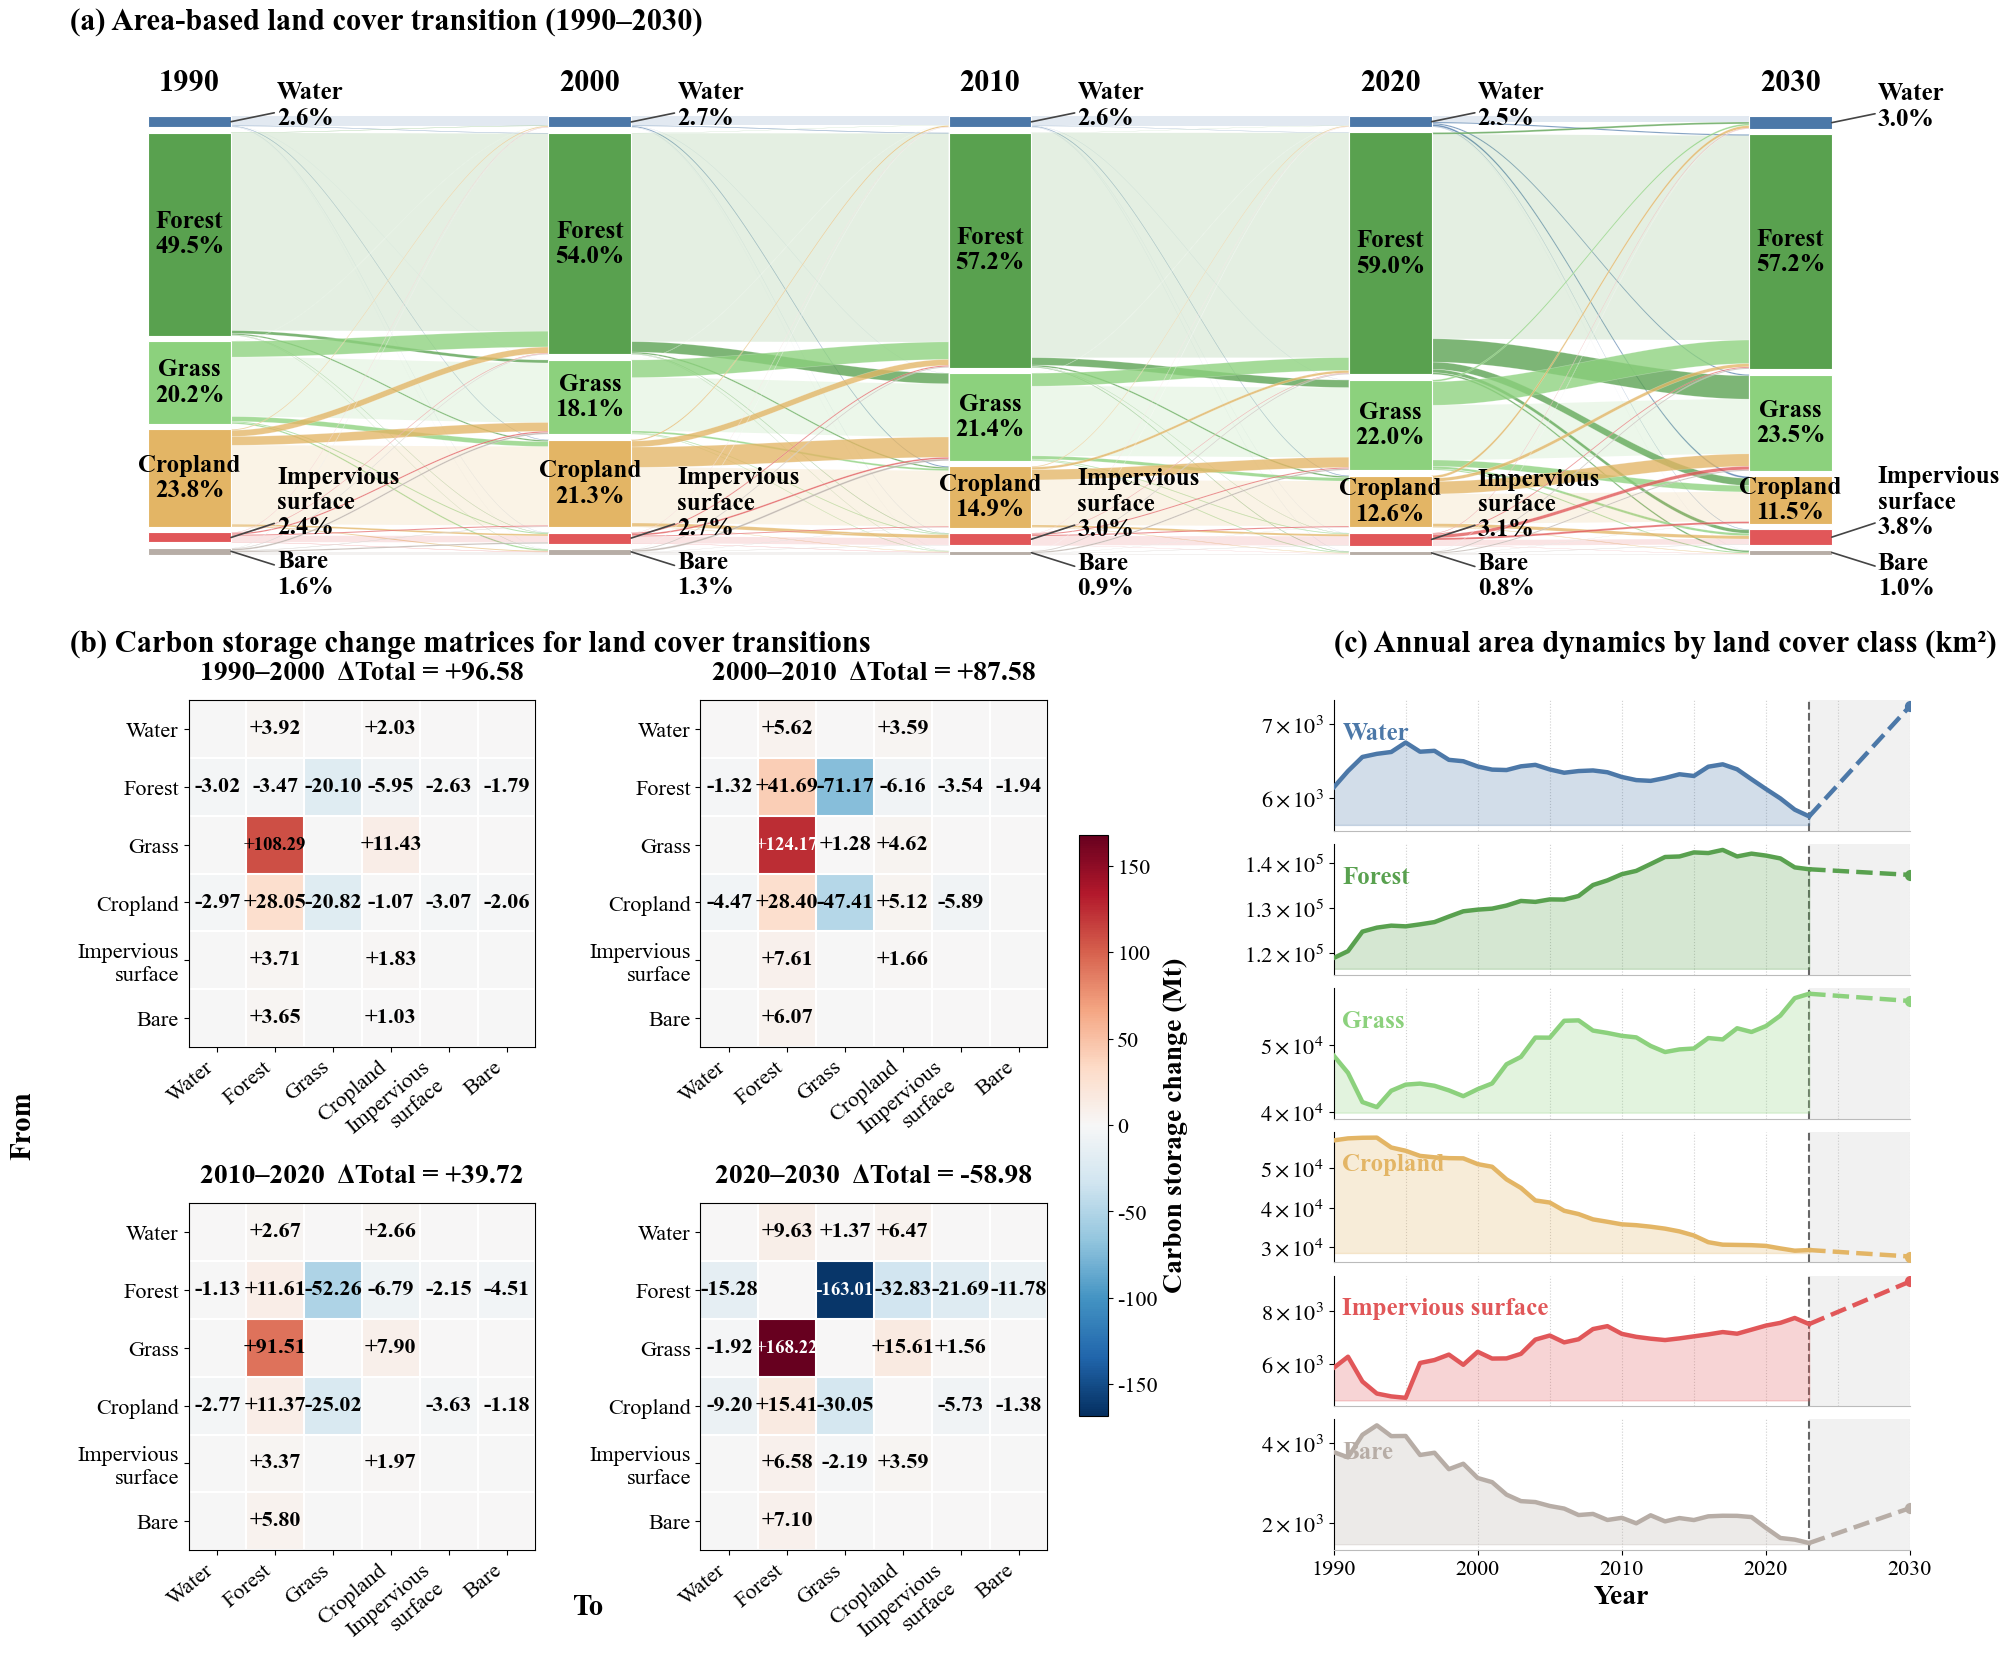


[已保存] H:\7.Eco_parameter\Figures\未来情景的变化转移图\Composite_LC_Carbon_1990_2030_Final.png / .pdf

Done. 所有排版已达到完美状态！


In [27]:
# -*- coding: utf-8 -*-
"""
1990-2030 湖南省土地覆盖变化路径与碳储量变化组合图 (顶级期刊极限大字号版)
------------------------------------------------
修改日志：
1. 全局字号飙升 (22/19/16级别)，彻底解决放入论文后看不清的问题。
2. 增大热力图内部纵向间距 (hspace=0.45)，完美解决上一排 X 轴标签与下一排标题的重叠。
3. 优化桑基图防重叠算法，适应新版特大字体。
4. 全局强制统一 Times New Roman 及其配套的数学公式字体。

作者：ChatGPT
依赖：pip install rasterio numpy pandas matplotlib
"""

import os
import re
import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, PathPatch, Patch
from matplotlib.path import Path
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker


# =========================================================
# 1. 路径与全局设置
# =========================================================
LC_DIR = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\annual_LC_from_1"
CS_DIR = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Carbon_Storage_correction"

LC_2030 = r"G:\Result_30m\Predicted\LC_2030_sim_from_2020.tif"
CS_2030 = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Carbon_Storage_2030_from_simLC\CS_total_2030.tif"

OUT_DIR = r"H:\7.Eco_parameter\Figures\未来情景的变化转移图"
os.makedirs(OUT_DIR, exist_ok=True)

YEARS = [1990, 2000, 2010, 2020, 2030]
INTERVALS = list(zip(YEARS[:-1], YEARS[1:]))
ANNUAL_YEARS = list(range(1990, 2024)) + [2030] 

PIXEL_SIZE_M = 30
PIXEL_AREA_KM2 = (PIXEL_SIZE_M * PIXEL_SIZE_M) / 1e6
CARBON_DIVISOR = 1e6
CARBON_UNIT_LABEL = "Mt"
BLOCK_SIZE = 1024
USE_COMMON_CARBON_MASK = True


# =========================================================
# 2. 分类编码与配色
# =========================================================
CLASS_MAP = {
    1: "Water", 2: "Forest", 3: "Grass",
    4: "Bare", 5: "Impervious surface", 6: "Cropland"
}

DISPLAY_NAMES = {
    1: "Water", 2: "Forest", 3: "Grass",
    4: "Bare", 5: "Impervious\nsurface", 6: "Cropland"
}

PLOT_ORDER = [1, 2, 3, 6, 5, 4]

CLASS_COLORS = {
    1: "#4C78A8", 2: "#59A14F", 3: "#8CD17D",
    4: "#B7ADA6", 5: "#E15759", 6: "#E3B565"
}


# =========================================================
# 3. 绘图风格与排版参数 (极限大字号设定)
# =========================================================
plt.style.use("default")
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix" 
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["figure.facecolor"] = "white"

# ！！！字号全面狂飙！！！
TITLE_SIZE = 22.0      # 主标题 (a), (b), (c)
AXIS_SIZE = 19.0       # 轴标签 From, To, Year
TICK_SIZE = 16.0       # 刻度数字与热力图XY刻度
ANNOT_SIZE = 18.0      # 桑基图大色块内部、折线图大标
HM_TEXT_SIZE = 16.0    # 热力图内部变动值
SMALL_ANNOT = 14.0     # 桑基图外部引线字

FIG_W = 20.0           # 略微加宽画布，适配硕大的字体
FIG_H = 16.5           # 加高画布，防止拥挤

NODE_GAP = 0.012
NODE_WIDTH = 0.045     # 节点加宽，容纳大号百分比
SELF_FLOW_ALPHA = 0.16
CHANGE_FLOW_ALPHA = 0.78
CHANGE_FLOW_LW = 0.45
HM_ANNOT_THRESHOLD = 1.0


# =========================================================
# 4. 数据处理核心逻辑 (复用已有逻辑，支持缓存)
# =========================================================
def hex_to_rgba(hex_color, alpha=0.35):
    hex_color = hex_color.lstrip("#")
    return (int(hex_color[0:2], 16)/255., int(hex_color[2:4], 16)/255., int(hex_color[4:6], 16)/255., alpha)

def iter_windows(width, height, block_size=1024):
    for row_off in range(0, height, block_size):
        h = min(block_size, height - row_off)
        for col_off in range(0, width, block_size):
            yield Window(col_off=col_off, row_off=row_off, width=min(block_size, width - col_off), height=h)

def find_year_file(folder, year, include_keywords=None):
    tif_files = glob.glob(os.path.join(folder, "*.tif"))
    pattern = re.compile(rf"(?<!\d){year}(?!\d)")
    matched = [f for f in tif_files if pattern.search(os.path.basename(f).lower())]
    if include_keywords:
        matched = [f for f in matched if any(k.lower() in os.path.basename(f).lower() for k in include_keywords)]
    return sorted(matched, key=lambda x: len(os.path.basename(x)))[0] if matched else None

def build_file_map():
    lc_files, cs_files = {}, {}
    for y in YEARS:
        if y == 2030: lc_files[y], cs_files[y] = LC_2030, CS_2030
        else:
            lc_files[y] = find_year_file(LC_DIR, y)
            cs_files[y] = find_year_file(CS_DIR, y, ["total"]) or find_year_file(CS_DIR, y)
    return lc_files, cs_files

def build_annual_lc_file_map():
    annual_lc_files = {}
    for y in ANNUAL_YEARS:
        if y == 2030: annual_lc_files[y] = LC_2030
        else:
            f = find_year_file(LC_DIR, y)
            if f: annual_lc_files[y] = f
    return annual_lc_files

def make_valid_lc_mask(arr, nodata):
    mask = np.isin(arr, list(CLASS_MAP.keys()))
    if nodata is not None: mask &= (arr != nodata)
    return mask

def make_valid_cs_mask(arr, nodata):
    mask = np.isfinite(arr) & (arr > -1e20) & (arr < 1e20)
    if nodata is not None and not np.isnan(nodata): mask &= (arr != nodata)
    return mask

def summarize_annual_lc(annual_lc_files):
    rows = []
    for y, f in annual_lc_files.items():
        with rasterio.open(f) as src:
            cnts = np.zeros(100, dtype=np.int64)
            for win in iter_windows(src.width, src.height, BLOCK_SIZE):
                arr = src.read(1, window=win)
                mask = make_valid_lc_mask(arr, src.nodata)
                if np.any(mask):
                    bc = np.bincount(arr[mask].astype(np.int16), minlength=100)
                    cnts[:len(bc)] += bc
            for c in CLASS_MAP.keys():
                rows.append({"year": y, "class_code": c, "area_km2": cnts[c] * PIXEL_AREA_KM2})
    return pd.DataFrame(rows)

def summarize_nodes_and_transitions(lc_files, cs_files):
    nc, ncarbon = {y: defaultdict(int) for y in YEARS}, {y: defaultdict(float) for y in YEARS}
    tc, tc0, tc1 = {intv: defaultdict(int) for intv in INTERVALS}, {intv: defaultdict(float) for intv in INTERVALS}, {intv: defaultdict(float) for intv in INTERVALS}
    lc_ds, cs_ds = {y: rasterio.open(lc_files[y]) for y in YEARS}, {y: rasterio.open(cs_files[y]) for y in YEARS}

    try:
        ref = lc_ds[YEARS[0]]
        for win in iter_windows(ref.width, ref.height, BLOCK_SIZE):
            common_mask = None
            lc_block, cs_block = {}, {}
            for y in YEARS:
                lca, csa = lc_ds[y].read(1, window=win), cs_ds[y].read(1, window=win).astype(np.float64)
                lc_block[y], cs_block[y] = lca, csa
                mask_y = make_valid_lc_mask(lca, lc_ds[y].nodata) & (make_valid_cs_mask(csa, cs_ds[y].nodata) if USE_COMMON_CARBON_MASK else True)
                common_mask = mask_y if common_mask is None else common_mask & mask_y

            if common_mask is None or not np.any(common_mask): continue

            for y in YEARS:
                lc_vals, cs_vals = lc_block[y][common_mask].astype(np.int16), cs_block[y][common_mask]
                bc_lc = np.bincount(lc_vals, minlength=7)
                bc_cs = np.bincount(lc_vals, weights=cs_vals, minlength=7)
                for c in CLASS_MAP.keys():
                    nc[y][c] += int(bc_lc[c])
                    ncarbon[y][c] += float(bc_cs[c])

            for y0, y1 in INTERVALS:
                lc0, lc1 = lc_block[y0][common_mask].astype(np.int16), lc_block[y1][common_mask].astype(np.int16)
                cs0, cs1 = cs_block[y0][common_mask], cs_block[y1][common_mask]
                code = lc0 * 10 + lc1
                bc_code, bc_c0, bc_c1 = np.bincount(code, minlength=100), np.bincount(code, weights=cs0, minlength=100), np.bincount(code, weights=cs1, minlength=100)
                for s in CLASS_MAP:
                    for t in CLASS_MAP:
                        idx = s * 10 + t
                        if bc_code[idx] > 0:
                            tc[(y0, y1)][(s, t)] += int(bc_code[idx])
                            tc0[(y0, y1)][(s, t)] += float(bc_c0[idx])
                            tc1[(y0, y1)][(s, t)] += float(bc_c1[idx])
    finally:
        for ds in lc_ds.values(): ds.close()
        for ds in cs_ds.values(): ds.close()
    return nc, ncarbon, tc, tc0, tc1

def build_dfs(nc, ncarbon, tc, tc0, tc1):
    rows_n, rows_t = [], []
    for y in YEARS:
        ta, tc_total = sum(nc[y].values()) * PIXEL_AREA_KM2, sum(ncarbon[y].values()) / CARBON_DIVISOR
        for c in PLOT_ORDER:
            rows_n.append({"year": y, "class_code": c, "area_km2": nc[y][c] * PIXEL_AREA_KM2, "area_share": (nc[y][c] * PIXEL_AREA_KM2)/ta if ta>0 else 0})
    
    for (y0, y1), d in tc.items():
        for s in PLOT_ORDER:
            for t in PLOT_ORDER:
                if d.get((s, t), 0) > 0:
                    rows_t.append({"year_from": y0, "year_to": y1, "source_code": s, "target_code": t, "area_km2": d[(s, t)] * PIXEL_AREA_KM2, "carbon_delta_mt": (tc1[(y0,y1)][(s,t)] - tc0[(y0,y1)][(s,t)]) / CARBON_DIVISOR})
    return pd.DataFrame(rows_n), pd.DataFrame(rows_t)


# =========================================================
# 5. 可视化绘制模块
# =========================================================

@ticker.FuncFormatter
def academic_sci_formatter(x, pos):
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    if np.isclose(coeff, 1.0):
        return f"$10^{{{exp}}}$"
    elif coeff.is_integer():
        return f"${int(coeff)} \\times 10^{{{exp}}}$"
    else:
        return f"${coeff:.1f} \\times 10^{{{exp}}}$"

def prepare_alluvial_geometry(node_df, trans_df):
    total_area = node_df[node_df["year"] == YEARS[0]]["area_km2"].sum()
    x_positions = dict(zip(YEARS, np.linspace(0.065, 0.935, len(YEARS)))) 
    node_pos, src_seg, tgt_seg = {}, {}, {}
    available_height = 0.94 - NODE_GAP * (len(PLOT_ORDER) - 1)

    for y in YEARS:
        current_top = 0.97
        for _, row in node_df[node_df["year"] == y].assign(order=lambda x: x["class_code"].map({c: i for i, c in enumerate(PLOT_ORDER)})).sort_values("order").iterrows():
            c, share = int(row["class_code"]), row["area_km2"] / total_area
            node_pos[(y, c)] = {"x0": x_positions[y]-NODE_WIDTH/2, "x1": x_positions[y]+NODE_WIDTH/2, "y0": current_top-share*available_height, "y1": current_top, "height": share*available_height, "share": share}
            current_top -= share*available_height + NODE_GAP

    for y0, y1 in INTERVALS:
        sub = trans_df[(trans_df["year_from"] == y0) & (trans_df["year_to"] == y1)]
        for s in PLOT_ORDER:
            cur = node_pos[(y0, s)]["y1"]
            for _, row in sub[sub["source_code"] == s].assign(to=lambda x: x["target_code"].map({c: i for i, c in enumerate(PLOT_ORDER)})).sort_values("to").iterrows():
                h = (row["area_km2"] / total_area) * available_height
                src_seg[(y0, y1, s, int(row["target_code"]))] = (cur-h, cur)
                cur -= h
        for t in PLOT_ORDER:
            cur = node_pos[(y1, t)]["y1"]
            for _, row in sub[sub["target_code"] == t].assign(so=lambda x: x["source_code"].map({c: i for i, c in enumerate(PLOT_ORDER)})).sort_values("so").iterrows():
                h = (row["area_km2"] / total_area) * available_height
                tgt_seg[(y0, y1, int(row["source_code"]), t)] = (cur-h, cur)
                cur -= h
    return x_positions, node_pos, src_seg, tgt_seg

def ribbon_patch(x0, x1, y0b, y0t, y1b, y1t, color, lw=0.0):
    t = np.linspace(0, 1, 100)
    s = 3 * t**2 - 2 * t**3
    xs = x0 + (x1 - x0) * t
    top, bot = y0t + (y1t - y0t) * s, y0b + (y1b - y0b) * s
    verts = np.column_stack([xs, top]).tolist() + np.column_stack([xs[::-1], bot[::-1]]).tolist() + [(xs[0], top[0])]
    codes = [Path.MOVETO] + [Path.LINETO]*(len(xs)-1) + [Path.LINETO]*len(xs) + [Path.CLOSEPOLY]
    return PathPatch(Path(verts, codes), facecolor=color, edgecolor=color if lw==0 else (1,1,1,0.3), lw=lw)

# (a) 绘制桑基图
def draw_alluvial(ax, node_df, trans_df):
    x_positions, node_pos, src_seg, tgt_seg = prepare_alluvial_geometry(node_df, trans_df)
    
    for y0, y1 in INTERVALS:
        for s in PLOT_ORDER:
            if (y0, y1, s, s) in src_seg:
                y0b, y0t = src_seg[(y0, y1, s, s)]; y1b, y1t = tgt_seg[(y0, y1, s, s)]
                ax.add_patch(ribbon_patch(node_pos[(y0, s)]["x1"], node_pos[(y1, s)]["x0"], y0b, y0t, y1b, y1t, hex_to_rgba(CLASS_COLORS[s], SELF_FLOW_ALPHA)))
            for t in PLOT_ORDER:
                if s != t and (y0, y1, s, t) in src_seg:
                    y0b, y0t = src_seg[(y0, y1, s, t)]; y1b, y1t = tgt_seg[(y0, y1, s, t)]
                    ax.add_patch(ribbon_patch(node_pos[(y0, s)]["x1"], node_pos[(y1, t)]["x0"], y0b, y0t, y1b, y1t, hex_to_rgba(CLASS_COLORS[s], CHANGE_FLOW_ALPHA), lw=CHANGE_FLOW_LW))

    # ================= 替换 draw_alluvial 函数中的这部分 =================
    for y in YEARS:
        for c in PLOT_ORDER:
            pos = node_pos[(y, c)]
            ax.add_patch(Rectangle((pos["x0"], pos["y0"]), pos["x1"]-pos["x0"], pos["height"], facecolor=CLASS_COLORS[c], edgecolor="white", lw=0.8, zorder=6))
            
            yc = (pos["y0"] + pos["y1"]) / 2
            share_pct = pos['share'] * 100
            
            if share_pct > 5.0:
                # 大面积地类，内部居中显示（使用 DISPLAY_NAMES 自动换行）
                label = f"{DISPLAY_NAMES[c]}\n{share_pct:.1f}%"
                ax.text((pos["x0"]+pos["x1"])/2, yc, label, ha="center", va="center", fontsize=ANNOT_SIZE, fontweight='bold', color="black", zorder=8)
            else:
                # 小面积地类，外部引线标注
                # 1. 【全称换行】：使用 DISPLAY_NAMES 提取带有 \n 的换行名称
                label_single = f"{DISPLAY_NAMES[c]}\n{share_pct:.1f}%"
                
                # 2. 【防重叠核心机制】：让 2020 年和 2030 年的小标签全部向右指！
                # 这样 2020 往右指，占据 2020-2030 空间；2030 往右指，占据 未来空间，彻底消灭“撞车”
                is_left_side = False  # 2020 和 2030 都向右指
                ha_align = "right" if is_left_side else "left"
                
                # 适当拉大引线的横向外推距离
                x_offset = 0.025 
                x_point = pos["x0"] if is_left_side else pos["x1"]
                x_text = x_point - x_offset if is_left_side else x_point + x_offset
                
                # 3. 【纵向防重叠】：由于采用了三行大字 (名称2行+比例1行)，必须大幅拉开上下错位
                y_text = yc
                if c == 1: y_text = yc + 0.035  # Water 往上拉
                if c == 5: y_text = yc + 0.075  # Impervious 往上拉更多（彻底避开Bare）
                if c == 4: y_text = yc - 0.050  # Bare 往下压
                
                ax.annotate(
                    label_single, xy=(x_point, yc), xytext=(x_text, y_text),
                    va="center", ha=ha_align, 
                    fontsize=ANNOT_SIZE, # 4. 【字号统一】：直接使用和 Forest 相同的 ANNOT_SIZE
                    fontweight='bold', color="black",
                    arrowprops=dict(arrowstyle="-", lw=1.2, color="#444444", shrinkA=0, shrinkB=0),
                    zorder=9
                )

    for y in YEARS: 
        ax.text(x_positions[y], 1.01, str(y), ha="center", va="bottom", fontsize=TITLE_SIZE, fontweight="bold")
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.06, 1.08) # 稍微拓展一点上下边界，防止大字体被裁掉
    ax.axis("off")
    ax.set_title("(a) Area-based land cover transition (1990–2030)", loc="left", fontsize=TITLE_SIZE, fontweight='bold', pad=25)
    # =====================================================================

# (b) 绘制热力图矩阵
def draw_heatmaps(fig, axs, trans_df):
    mats = {}
    vmax = 0.0
    for y0, y1 in INTERVALS:
        mat = np.zeros((len(PLOT_ORDER), len(PLOT_ORDER)))
        sub = trans_df[(trans_df["year_from"]==y0) & (trans_df["year_to"]==y1)]
        for _, row in sub.iterrows(): mat[PLOT_ORDER.index(row["source_code"]), PLOT_ORDER.index(row["target_code"])] = row["carbon_delta_mt"]
        mats[(y0, y1)] = mat
        vmax = max(vmax, np.nanmax(np.abs(mat)))

    vmax = vmax if vmax > 0 else 1.0
    norm, cmap = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax), plt.get_cmap("RdBu_r")
    
    labels = [DISPLAY_NAMES[c] for c in PLOT_ORDER]
    im_ref = None

    for ax, (y0, y1) in zip(axs, INTERVALS):
        mat = mats[(y0, y1)]
        im_ref = ax.imshow(mat, cmap=cmap, norm=norm, aspect="equal")
        ax.set_xticks(range(len(PLOT_ORDER)))
        ax.set_yticks(range(len(PLOT_ORDER)))
        
        ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=TICK_SIZE)
        ax.set_yticklabels(labels, fontsize=TICK_SIZE)
        
        ax.set_title(f"{y0}–{y1}  ΔTotal = {np.nansum(mat):+.2f}", fontsize=AXIS_SIZE+1, fontweight='bold', pad=15)
        
        ax.set_xticks(np.arange(-.5, len(PLOT_ORDER), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(PLOT_ORDER), 1), minor=True)
        ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)

        for i in range(len(PLOT_ORDER)):
            for j in range(len(PLOT_ORDER)):
                if abs(mat[i, j]) >= HM_ANNOT_THRESHOLD:
                    text_str = f"{mat[i,j]:+.2f}"
                    fs = HM_TEXT_SIZE if len(text_str) <= 6 else HM_TEXT_SIZE - 2.5
                    ax.text(j, i, text_str, ha="center", va="center", fontsize=fs, fontweight='bold', color="black" if abs(mat[i,j]) < 0.65*vmax else "white")

    cbar = fig.colorbar(im_ref, ax=axs, fraction=0.028, pad=0.03)  # 增大fraction参数使colorbar更长
    cbar.set_label(f"Carbon storage change ({CARBON_UNIT_LABEL})", fontsize=AXIS_SIZE+1, fontweight='bold')
    cbar.ax.tick_params(labelsize=TICK_SIZE)

# (c) 绘制多层嵌套折线图
def draw_facet_line_charts(axs, annual_df):
    for i, c in enumerate(PLOT_ORDER):
        ax = axs[i]
        sub = annual_df[annual_df['class_code'] == c].sort_values('year')
        hist = sub[sub['year'] <= 2023]
        
        ax.axvspan(2023, 2030, facecolor='#EEEEEE', alpha=0.8, zorder=0)
        ax.axvline(2023, color='#666666', linestyle='--', lw=1.5, zorder=1)
        
        if not hist.empty:
            ax.plot(hist['year'], hist['area_km2'], '-', color=CLASS_COLORS[c], lw=3.2, zorder=3)
            ax.fill_between(hist['year'], hist['area_km2'], hist['area_km2'].min() * 0.98, color=CLASS_COLORS[c], alpha=0.25, zorder=2)
            
            if 2030 in sub['year'].values:
                fut = sub[sub['year'] >= hist['year'].iloc[-1]]
                ax.plot(fut['year'], fut['area_km2'], '--', color=CLASS_COLORS[c], lw=3.2, zorder=3)
                ax.scatter(2030, fut[fut['year']==2030]['area_km2'].iloc[0], color=CLASS_COLORS[c], s=50, zorder=4)
        
        ax.set_xlim(1990, 2030)
        
        ax.locator_params(axis='y', nbins=3) 
        ax.yaxis.set_major_formatter(academic_sci_formatter) 
        ax.tick_params(axis='y', labelsize=TICK_SIZE)
        
        ax.text(0.015, 0.70, CLASS_MAP[c], transform=ax.transAxes, color=CLASS_COLORS[c], fontsize=ANNOT_SIZE, fontweight='bold', zorder=5)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color('#BBBBBB')
        ax.grid(axis='x', linestyle=':', alpha=0.6)

        if i < len(PLOT_ORDER) - 1:
            ax.tick_params(labelbottom=False, bottom=False) 
        else:
            ax.set_xticks([1990, 2000, 2010, 2020, 2030])
            ax.set_xlabel("Year", fontsize=AXIS_SIZE+1, fontweight='bold')
            ax.tick_params(axis='x', labelsize=TICK_SIZE)

    axs[0].set_title("(c) Annual area dynamics by land cover class (km²)", loc="left", fontsize=TITLE_SIZE, fontweight='bold', pad=35)


# =========================================================
# 6. 全局组合排版 (极限紧凑 + 防重叠)
# =========================================================
def make_composite_figure(annual_df, node_df, trans_df, out_dir):
    fig = plt.figure(figsize=(FIG_W, FIG_H), constrained_layout=False)
    
    # 【核心调整】：hspace=0.15 极度缩小 A图与下方的断层感
    gs_main = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.6], hspace=0.15, left=0.04, right=0.96, top=0.96, bottom=0.06)

    ax_alluvial = fig.add_subplot(gs_main[0])
    draw_alluvial(ax_alluvial, node_df, trans_df)

    gs_bottom = gs_main[1].subgridspec(1, 2, width_ratios=[1.8, 1.0], wspace=0.28)

    ax_hm_bg = fig.add_subplot(gs_bottom[0])
    ax_hm_bg.spines['top'].set_visible(False)
    ax_hm_bg.spines['right'].set_visible(False)
    ax_hm_bg.spines['bottom'].set_visible(False)
    ax_hm_bg.spines['left'].set_visible(False)
    ax_hm_bg.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    
    ax_hm_bg.set_xlabel("To", fontsize=AXIS_SIZE+2, fontweight='bold', labelpad=15)
    ax_hm_bg.set_ylabel("From", fontsize=AXIS_SIZE+2, fontweight='bold', labelpad=5) 
    ax_hm_bg.set_title("(b) Carbon storage change matrices for land cover transitions", loc="left", fontsize=TITLE_SIZE, fontweight='bold', pad=35)

    # 【核心调整】：hspace=0.45 极限拉开热力图上下间距，彻底消除重叠
    gs_hm = gs_bottom[0].subgridspec(2, 2, wspace=0.10, hspace=0.45)
    ax_hm1 = fig.add_subplot(gs_hm[0, 0])
    ax_hm2 = fig.add_subplot(gs_hm[0, 1])
    ax_hm3 = fig.add_subplot(gs_hm[1, 0])
    ax_hm4 = fig.add_subplot(gs_hm[1, 1])
    draw_heatmaps(fig, [ax_hm1, ax_hm2, ax_hm3, ax_hm4], trans_df)

    gs_lines = gs_bottom[1].subgridspec(6, 1, hspace=0.10) 
    axs_lines = [fig.add_subplot(gs_lines[i]) for i in range(6)]
    draw_facet_line_charts(axs_lines, annual_df)

    base = os.path.join(out_dir, "Composite_LC_Carbon_1990_2030_Final")
    fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
    fig.savefig(base + ".pdf", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n[已保存] {base}.png / .pdf")


# =========================================================
# 7. 主程序
# =========================================================
def main():
    print("=== 开始处理 1990-2030 时空动态制图 (期刊极限大字号出图版) ===")
    
    annual_csv = os.path.join(OUT_DIR, "annual_lc_stats_1990_2030.csv")
    if os.path.exists(annual_csv):
        annual_df = pd.read_csv(annual_csv)
    else:
        annual_df = summarize_annual_lc(build_annual_lc_file_map())
        annual_df.to_csv(annual_csv, index=False, encoding="utf-8-sig")

    node_csv = os.path.join(OUT_DIR, "node_stats_1990_2030.csv")
    trans_csv = os.path.join(OUT_DIR, "transition_stats_1990_2030.csv")
    
    if os.path.exists(node_csv) and os.path.exists(trans_csv):
        node_df, trans_df = pd.read_csv(node_csv), pd.read_csv(trans_csv)
    else:
        lc_files, cs_files = build_file_map()
        nc, ncarbon, tc, tc0, tc1 = summarize_nodes_and_transitions(lc_files, cs_files)
        node_df, trans_df = build_dfs(nc, ncarbon, tc, tc0, tc1)
        node_df.to_csv(node_csv, index=False, encoding="utf-8-sig")
        trans_df.to_csv(trans_csv, index=False, encoding="utf-8-sig")

    make_composite_figure(annual_df, node_df, trans_df, OUT_DIR)
    print("\nDone. 所有排版已达到完美状态！")

if __name__ == "__main__":
    main()